## Reading in a short story as text sample into Python

### Step 1 : Creating Tokens

In [1]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

print("Total number of character : ", len(raw_text)) ## print total character
print(raw_text[:99]) ## prints first 100

Total number of character :  20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


#### Tokenize all 20479 words into token so they can later be converted to vector embeddings

In [2]:
import re

# Tokenize into words and punctuation
tokens = re.findall(r"\w+|[^\w\s]", raw_text)

# Display results
print("Total tokens:", len(tokens))
print(tokens[:50])   # First 50 tokens

Total tokens: 4827
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '-', '-', 'though', 'a', 'good', 'fellow', 'enough', '-', '-', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in', 'the', 'height', 'of', 'his', 'glory', ',', 'he', 'had', 'dropped', 'his', 'painting', ',', 'married', 'a', 'rich', 'widow', ',', 'and']


### Step 2 : Token Ids

#### Build vocabulary by sorting unique tokens in alphabetical order and providing it ID

In [3]:
all_words = sorted(set(tokens))
vocab_size = len(all_words)
print(vocab_size)

1148


In [4]:
vocab = {token:integer for integer,token in enumerate(all_words)}

In [5]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s, i in vocab.items()}

    def encode(self, text):
        tokens = re.findall(r"\w+|[^\w\s]", text)

        tokens = [item.strip() for item in tokens if item.strip()]
        ids = [self.str_to_int[s] for s in tokens]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [6]:
tokenizer = SimpleTokenizerV1(vocab)

text = "It's the last he painted, you know"
ids = tokenizer.encode(text)
print(ids)

[56, 2, 867, 1006, 615, 546, 760, 5, 1144, 609]


In [7]:
print(tokenizer.decode(ids))

It' s the last he painted, you know


## Adding Special Context Tokens
#### Modify tokenizer to handle unknown vocab - <|unk|> and <|endoftext|> both of these are added to vocab as fallback. <|endoftext|> added b/w different source of text

In [8]:
all_tokens = sorted(set(tokens))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
all_vocab = {token:integer for integer,token in enumerate(all_tokens)}
len(all_vocab.items())

1150

In [9]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s, i in vocab.items()}

    def encode(self, text):
        tokens = re.findall(r"<\|endoftext\|>|<\|unk\|>|\w+|[^\w\s]",text)

        tokens = [item.strip() for item in tokens if item.strip()]
        tokens = [item if item in self.str_to_int
                 else "<|unk|>" for item in tokens]
        ids = [self.str_to_int[s] for s in tokens]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [10]:
tokenizer2 = SimpleTokenizerV2(all_vocab)

text1 = "Hello, do you like tea?"
text2 = "Darjeeling tea is the best!"
text = " <|endoftext|> ".join((text1, text2))
ids = tokenizer2.encode(text)
print(text)

Hello, do you like tea? <|endoftext|> Darjeeling tea is the best!


In [11]:
print(tokenizer2.decode(ids))

<|unk|>, do you like tea? <|endoftext|> <|unk|> tea is the <|unk|>!


### BYTE PAIR ENCODING (BPE)
##### BPE is used to train LLMs such as GPT-2, GPT-3

In [12]:
! pip install tiktoken

In [13]:
import importlib
import tiktoken

print("tiktoken version: ", importlib.metadata.version("tiktoken")) 

tiktoken version:  0.13.0


In [14]:
tokenizer = tiktoken.get_encoding("gpt2")

In [15]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    "of someunknownPlace."
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [16]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


### Let us take another simple example to illustrate how the BPE tokenizer deals with unknowm tokens

In [17]:
integers = tokenizer.encode("Akwirw ier")
print(integers)
strings = tokenizer.decode(integers)
print(strings)

[33901, 86, 343, 86, 220, 959]
Akwirw ier


### CREATING INPUT-TARGET PAIRS
#### In this section, implemented a data loader that fetches the input-target pairs using a sliding window approach
#### Tokenize the whole The Verdict short story using BPE tokenizer

In [18]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


#### context size = input size based on which model gives the output

In [19]:
context_size = 4
x = enc_text[:context_size]
y = enc_text[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

x: [40, 367, 2885, 1464]
y:      [367, 2885, 1464, 1807]


In [20]:
for i in range(1, context_size+1):
    context = enc_text[:i]
    desired = enc_text[i]

    print(context, "---->", desired)

## Left - Input Pair || Right -> Target
## One input-output pair -> number of prediction task as set by context size

[40] ----> 367
[40, 367] ----> 2885
[40, 367, 2885] ----> 1464
[40, 367, 2885, 1464] ----> 1807


In [21]:
for i in range(1, context_size+1):
    context = enc_text[:i]
    desired = enc_text[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

I ---->  H
I H ----> AD
I HAD ---->  always
I HAD always ---->  thought


### Implement a Data Loader

```
Step 1: Tokenize the text
Step 2: Sliding window to chuck the book into overlapping sequences of max_lenght
Step 3: Return the total number of rows in the dataset
Step 4: Return a single row from the dataset
```

In [22]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # use sliding window to chunk the book into overlapping seq of max_lengths
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
            return len(self.input_ids)

    def __getitem__(self, idx):
            return self.input_ids[idx], self.target_ids[idx]

## GPTDatasetV1 Defines how individual rows are fetched from the dataset, each row consists of a
## number of token IDs (based on max_length/context_size) assigned to an input_chunk
## tensor. The target_chunk tensor contains the corresponding targets. 

```
Step 1: Intialize the tokenizer
Step 2: Create dataset
Step 3: drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training
Step 4: The number of CPU processes to use for preprocessing
```

In [23]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                     stride=128, shuffle=True, drop_last=True,
                     num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [24]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

In [25]:
import torch
dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1,
                                  shuffle=False)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [26]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


In [27]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4,
                                  shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs\n : ", inputs)
print("Targets\n : ", targets)

Inputs
 :  tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Targets
 :  tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


## Creating Token Embeddings

In [28]:
##Token Id to embedding vector conversion

input_ids = torch.tensor([2, 3, 5, 1])

```
Example :
Quick : 4
fox : 0
is : 3
in : 2
the : 5
house : 1
```

In [29]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [30]:
print(embedding_layer.weight) ## gives initial weights

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [31]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [32]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


### Positional Embeddings (Encoding word positions)

In [33]:
vocab_size = 50257 
output_dim = 256 ##vector dimension

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [34]:
context_size = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=context_size,
    stride=context_size, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [35]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [36]:
token_embedding = token_embedding_layer(inputs)
print(token_embedding.shape)

torch.Size([8, 4, 256])


In [37]:
context_length = context_size
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [38]:
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


#### Need only 4 positional embedding
```
* Context length tells how many token positions exist in each input sequence
* position is for context length token and does for all tokens

```

In [39]:
input_embeddings = token_embedding + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


###  Simplified Attention Mechanism

In [40]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your       (x^1)
     [0.55, 0.87, 0.66],  # journey    (x^2)
     [0.57, 0.85, 0.64],  # starts     (x^3)
     [0.22, 0.58, 0.33],  # with       (x^4)
     [0.77, 0.25, 0.10],  # one        (x^5)
     [0.05, 0.80, 0.55]]  # step       (x^6)
)

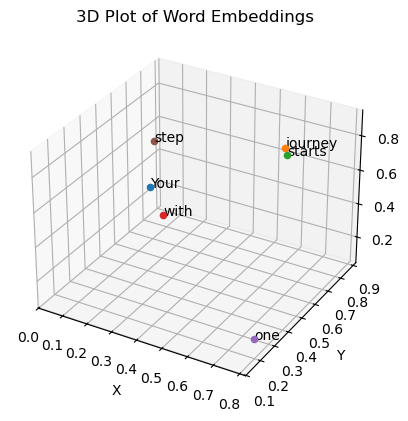

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

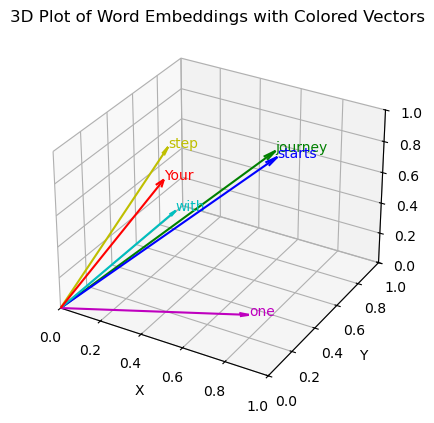

In [42]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


<div class="alert alert-block alert-info">
    
Each row represents a word, and each column represents an embedding dimension

The second input token serves as the query
</div>

In [43]:
query = inputs[1]  # 2nd input token is the query

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


#### Normalization the attention score : why -> to get % of attention to be given to each word. Obtain attention weight that sum upto 1, helps with training as well

In [44]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weights : ", attn_weights_2_tmp)
print("Sum : ", attn_weights_2_tmp.sum())

## attention_weight sum upto 1, attention_scores don't
## for normalization, use softmax, normalize in such a way so that very small has 0 weightage
## that's why use softmax = e^i/(sum(e^j)

Attention weights :  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum :  tensor(1.0000)


In [45]:
attn_weights_2 = torch.softmax(attn_scores_2, dim = 0)
print("Attention weights : ", attn_weights_2)
print("Sum : ", attn_weights_2.sum())

## context vector for journey based on these weights

Attention weights :  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum :  tensor(1.)


### context vector = input_token(i) * attention_weight(i)

In [46]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


```
- compute attention scores (as dot products b/w the inputs)
- compute attention weigths (normalized versions of the attention scores)
- compute context vectors (weighted sum over the inputs / attn_weights @ inputs)
```

In [47]:
print(len(inputs))
attn_scores = torch.empty(len(inputs), len(inputs))

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

6
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [48]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [50]:
attn_weights = torch.softmax(attn_scores, dim = 1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [51]:
all_contxt_vecs = attn_weights @ inputs
print(all_contxt_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [53]:
print("Previous 2nd context vector : ", context_vec_2)

Previous 2nd context vector :  tensor([0.4419, 0.6515, 0.5683])
